CSW VS ASW CON logFC=2

Cargando paquete requerido: S4Vectors

Cargando paquete requerido: stats4

Cargando paquete requerido: BiocGenerics

Cargando paquete requerido: generics


Adjuntando el paquete: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Adjuntando el paquete: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Adjuntando el paquete: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    fin

# A tibble: 3 × 2
  regulation            n
  <fct>             <int>
1 Subexpresado       7428
2 No significativo 109551
3 Sobreexpresado     4027


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,regulation
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
pelegrina_gene1000352_i1,8.101986,-5.870020,1.3730483,-4.275174,1.909883e-05,1.668556e-04,Subexpresado
pelegrina_gene100087_i1,4.621641,6.164505,1.5657457,3.937105,8.247052e-05,6.322095e-04,Sobreexpresado
pelegrina_gene1000884_i1,6.065661,6.448745,1.4350684,4.493685,7.000129e-06,6.635199e-05,Sobreexpresado
pelegrina_gene1002000_i1,3.515834,5.655355,1.6220039,3.486647,4.891165e-04,3.093283e-03,Sobreexpresado
pelegrina_gene1002097_i1,9.370611,-2.197488,0.7581414,-2.898520,3.749283e-03,1.844652e-02,Subexpresado
pelegrina_gene1002897_i1,44.198160,-3.868198,0.4474324,-8.645323,5.365338e-18,1.809654e-16,Subexpresado



out of 121085 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 15358, 13%
LFC < 0 (down)     : 18856, 16%
outliers [1]       : 33, 0.027%
low counts [2]     : 0, 0%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



[1] 11455

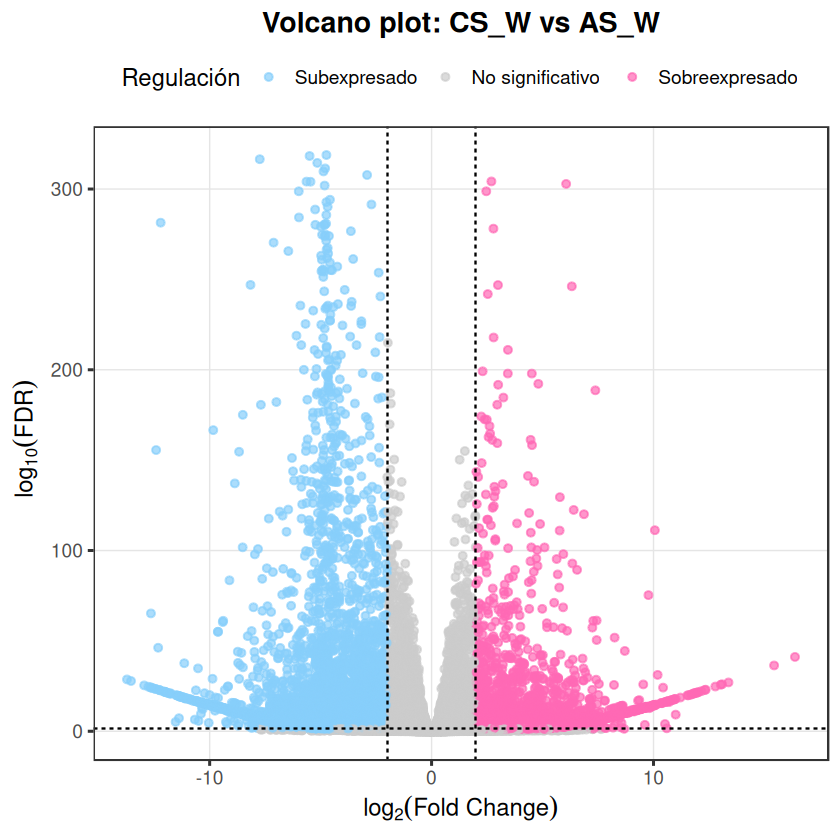

Genes fondo: 44038 
DEGs: 11455 
DEGs con KEGG: 584 


agg_record_bad25110c104 
                      2

,Description,Count,GeneRatio,p.adjust
,<chr>,<int>,<chr>,<dbl>
map00940,Phenylpropanoid biosynthesis,27,27/584,3.072151e-14
map05145,Toxoplasmosis,12,12/584,3.024896e-04
map00073,"Cutin, suberine and wax biosynthesis",8,8/584,9.756642e-04
map03030,DNA replication,15,15/584,9.756642e-04
map04976,Bile secretion,9,9/584,1.416926e-03
map05202,Transcriptional misregulation in cancer,10,10/584,7.917779e-03
map04072,Phospholipase D signaling pathway,13,13/584,1.397297e-02
map05146,Amoebiasis,10,10/584,2.662890e-02
map02010,ABC transporters,8,8/584,2.957781e-02


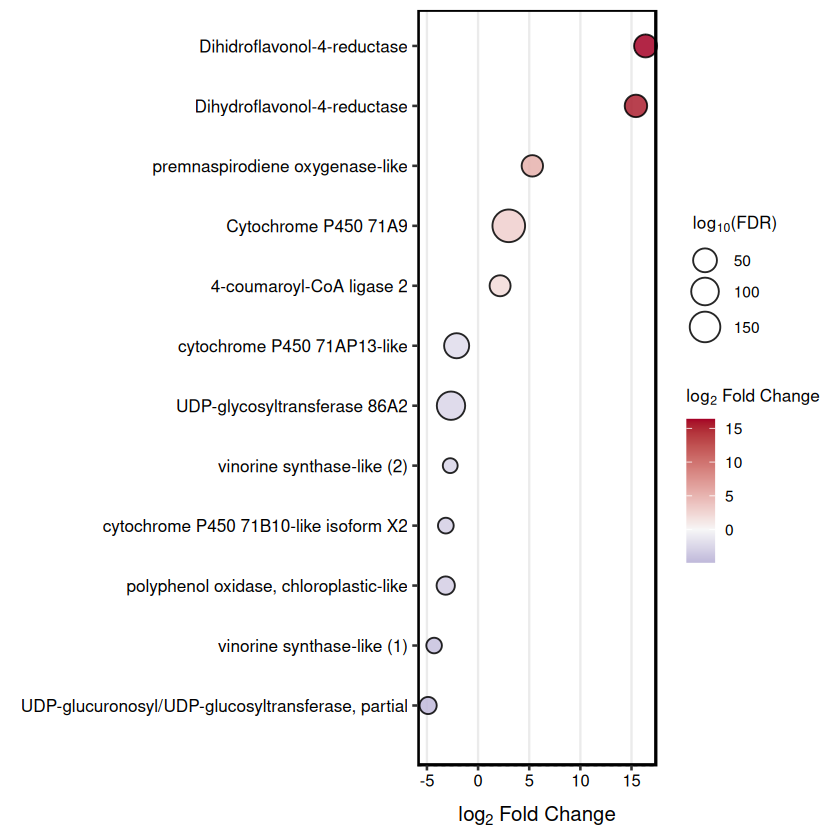

In [ ]:
################################################
#CSW_VS_ASW CON LogFC=2
################################################
setwd("/home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA")

library(tximport)
library(DESeq2)
library(dplyr)
library(ggplot2)
library(clusterProfiler)
library(enrichplot)
library(tidyr)
# ===============================
# 1. Muestras
# ===============================
samples <- c(
  "AS_WO_R1","AS_WO_R2","AS_WO_R3",
  "AS_W_R1","AS_W_R2","AS_W_R3",
  "CS_W_R1","CS_W_R2","CS_W_R3"
)

files <- file.path("Counts_2", paste0(samples, ".sf"))
names(files) <- samples

# ===============================
# 2. Importación
# ===============================
txi <- tximport(
  files,
  type = "salmon",
  txOut = TRUE,
  importer = function(x) {
    read.delim(x, check.names = FALSE) %>%
      arrange(Name)
  }
)

# ===============================
# 3. Metadata
# ===============================
coldata <- data.frame(
  row.names = samples,
  condition = c(
    "AS_WO","AS_WO","AS_WO",
    "AS_W","AS_W","AS_W",
    "CS_W","CS_W","CS_W"
  )
)

coldata$condition <- factor(
  coldata$condition,
  levels = c("AS_WO", "AS_W", "CS_W")
)

# ===============================
# 4. Crear objeto DESeq2
# ===============================
dds <- DESeqDataSetFromTximport(
  txi,
  colData = coldata,
  design = ~ condition
)

# ===============================
# 5. Filtrado
# ===============================
dds <- dds[rowSums(counts(dds) >= 5) >= 3, ]

# ===============================
# 6. DESeq2
# ===============================
dds <- DESeq(dds)

# ===============================
# 7. Resultados
# ===============================
res_CSW_vs_ASW <- results(
  dds,
  contrast = c("condition", "CS_W", "AS_W")
)

# ===============================
# 8. Parámetros
# ===============================
lfc_cutoff <- 2
padj_cutoff <- 0.05

# ===============================
# 9. Dataframe base
# ===============================
res_df <- as.data.frame(res_CSW_vs_ASW)

# ===============================
# 10. Dataframe para plots
# ===============================
res_plot <- res_df %>%
  filter(!is.na(padj), padj > 0) %>%
  mutate(
    regulation = case_when(
      padj < padj_cutoff & log2FoldChange >= lfc_cutoff  ~ "Sobreexpresado",
      padj < padj_cutoff & log2FoldChange <= -lfc_cutoff ~ "Subexpresado",
      TRUE ~ "No significativo"
    )
  )

# ===============================
# 11. Orden de la leyenda
# ===============================
res_plot$regulation <- factor(
  res_plot$regulation,
  levels = c(
    "Subexpresado",
    "No significativo",
    "Sobreexpresado"
  )
)

# ===============================
# 12. Conteo de genes
# ===============================
conteo_genes <- res_plot %>%
  group_by(regulation) %>%
  summarise(n = n())

print(conteo_genes)

# ===============================
# 13. Filtrado DEG
# ===============================
res_filtrado <- res_plot %>%
  filter(
    padj < padj_cutoff,
    abs(log2FoldChange) >= lfc_cutoff
  )

# ===============================
# 14. Output
# ===============================
head(res_filtrado)
summary(res_CSW_vs_ASW)
nrow(res_filtrado)

write.csv(
  res_filtrado,
  "DEG_CSW_vs_ASW_logFC2.csv",
  row.names = TRUE
)

# ===============================
# 15. Volcano plot
# ===============================
p1 <- ggplot(
  res_plot,
  aes(
    x = log2FoldChange,
    y = -log10(padj)
  )
) +
  
  geom_point(
    aes(color = regulation),
    alpha = 0.7,
    size = 1.5
  ) +
  
  geom_vline(
    xintercept = c(-lfc_cutoff, lfc_cutoff),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  
  geom_hline(
    yintercept = -log10(padj_cutoff),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  
  scale_color_manual(values = c(
    "Subexpresado" = "#87CEFA",
    "No significativo" = "grey80",
    "Sobreexpresado" = "#FF69B4"
  )) +
  
  labs(
    title = "Volcano plot: CS_W vs AS_W",
    x = expression(log[2]("Fold Change")),
    y = expression(-log[10](FDR)),
    color = "Regulación"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    legend.position = "top",
    
    plot.title = element_text(
      face = "bold",
      hjust = 0.5
    ),
    
    panel.grid.major = element_line(
      color = "grey90",
      linewidth = 0.3
    ),
    
    panel.grid.minor = element_blank()
  )

# ===============================
# Guardar volcano plot
# ===============================
ggsave(
  filename = "Volcano_CSW_vs_ASW_logFC2.png",
  plot = p1,
  width = 10,
  height = 8,
  dpi = 300,
  bg = "white"
)

# Mostrar volcano
print(p1)

# ===============================
# 16. Genes de interés
# ===============================
genes_interes <- c(
  
  "pelegrina_gene1037623_i3",
  "pelegrina_gene823968_i2",
  "pelegrina_gene1039844_i1",
  "pelegrina_gene1452632_i3",
  "pelegrina_gene1913168_i5",
  "pelegrina_gene1168858_i3",
  "pelegrina_gene829540_i1",
  "pelegrina_gene1057551_i1",
  "pelegrina_gene835130_i1",
  "pelegrina_gene1164041_i10",
  "pelegrina_gene1156448_i15",
  "pelegrina_gene1845786_i2"
)

# ===============================
# 17. Descripciones
# ===============================
descripciones <- data.frame(
  gene = c(
    "pelegrina_gene1037623_i3",
    "pelegrina_gene823968_i2",
    "pelegrina_gene1039844_i1",
    "pelegrina_gene1452632_i3",
    "pelegrina_gene1913168_i5",
    "pelegrina_gene1168858_i3",
    "pelegrina_gene829540_i1",
    "pelegrina_gene1057551_i1",
    "pelegrina_gene835130_i1",
    "pelegrina_gene1164041_i10",
    "pelegrina_gene1156448_i15",
    "pelegrina_gene1845786_i2"
    
  ),
  
  descripcion = c(
    "polyphenol oxidase, chloroplastic-like [Typha latifolia].",
    "cytochrome P450 71AP13-like [Dioscorea cayenensis subsp. Rotundata]",
    "UDP-glucuronosyl/UDP-glucosyltransferase, partial [Trema orientale]",
    "cytochrome P450 71B10-like isoform X2 [Telopea speciosissima].",
    "vinorine synthase-like [Papaver somniferum].",
    "vinorine synthase-like [Papaver somniferum].",
    "4-coumaroyl-CoA ligase 2 [Crocosmia x crocosmiiflora]",
    "Cytochrome P450 71A9 [Ananas comosus]",
    "premnaspirodiene oxygenase-like [Phoenix dactylifera].",
    "UDP-glycosyltransferase 86A2 [Juglans regia].",
    "Dihydroflavonol-4-reductase",
    "Dihidroflavonol-4-reductase"
  )
)

# ===============================
# 18. Subset resultados
# ===============================
subset_res <- res_df[
  rownames(res_df) %in% genes_interes,
]

subset_res$gene <- rownames(subset_res)

# ===============================
# 19. Agregar descripciones
# ===============================
subset_res <- merge(
  subset_res,
  descripciones,
  by = "gene"
)

# ==============================================================================
# 20. Filtrar y limpiar descripciones 
# ==============================================================================
subset_res <- subset_res %>%
  filter(!is.na(padj), padj > 0)

subset_res$descripcion_limpia <- sub("\\s*\\[.*\\]", "", subset_res$descripcion)
subset_res$descripcion_limpia <- sub("\\.$", "", subset_res$descripcion_limpia)

# ==============================================================================
# Diferenciar nombres duplicados automáticamente
# ==============================================================================
subset_res <- subset_res %>%
  group_by(descripcion_limpia) %>%
  mutate(
    descripcion_grafico = if(n() > 1) {
      paste0(descripcion_limpia, " (", row_number(), ")")
    } else {
      descripcion_limpia
    }
  ) %>%
  ungroup()

# ==============================================================================
# Ordenar dataframe y asignar etiquetas únicas
# ==============================================================================
# Ordenamos por log2FoldChange
subset_res <- subset_res[order(subset_res$log2FoldChange), ]

subset_res$label <- factor(
  subset_res$descripcion_grafico, 
  levels = subset_res$descripcion_grafico
)

# ==============================================================================
# Bubble plot 
# ==============================================================================
p2 <- ggplot(
  subset_res,
  aes(
    x = label,         
    y = log2FoldChange,
    fill = log2FoldChange,  
    size = -log10(padj)
  )
) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray60", linewidth = 0.4) +
  geom_point(shape = 21, color = "black", alpha = 0.85, stroke = 0.6) +
  coord_flip() +
  
  scale_fill_gradient2(
    low = "#313695",     
    mid = "#f7f7f7",     
    high = "#a50026",    
    midpoint = 0,
    name = expression(log[2] * " Fold Change")
  ) +
  
  scale_size_continuous(
    range = c(3.5, 8.5), 
    name = expression(-log[10] * "(FDR)")
  ) +
  
  labs(
    x = NULL,            
    y = expression(log[2] * " Fold Change")
  ) +
  
  theme_bw(base_size = 12) +
  theme(
    panel.grid.major.x = element_line(color = "gray92", linewidth = 0.5),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    
    axis.text.x = element_text(color = "black"),
    axis.text.y = element_text(color = "black", size = 10), 
    axis.title.x = element_text(face = "bold", margin = margin(t = 10)),
    
    legend.position = "right",
    legend.title = element_text(size = 10, face = "bold"),
    legend.text = element_text(size = 9),
    legend.background = element_blank(),
    legend.box.background = element_blank()
  )

# Guardar
ggsave(
  filename = "BubblePlot_PigmentGenes_C_AW_fixed.png",
  plot = p2,
  width = 9.5,
  height = 5.5,
  dpi = 300,
  bg = "white"
)

print(p2)

################################################
# KEGG ENRICHMENT
################################################

library(clusterProfiler)
library(enrichplot)
library(tidyr)

# ===============================
# Gene -> KO
# ===============================

ko_gene <- read.delim(
  "KO.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(ko_gene) <- c("gene","KO")

ko_gene$gene <- sub(
  "\\.p[0-9]+$",
  "",
  ko_gene$gene
)

# ===============================
# KO -> Pathway
# ===============================

ko2path <- read.delim(
  "ko2pathway.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(ko2path) <- c(
  "KO",
  "Pathway"
)

ko2path$KO <- sub("^ko:", "", ko2path$KO)
ko2path$Pathway <- sub("^path:", "", ko2path$Pathway)

# ===============================
# Gene -> Pathway
# ===============================

gene2path <- merge(
  ko_gene,
  ko2path,
  by = "KO"
)

gene2path$Pathway <- sub(
  "^ko",
  "map",
  gene2path$Pathway
)

gene2path <- gene2path %>%
  distinct(
    gene,
    Pathway,
    .keep_all = TRUE
  )

# ===============================
# Pathway names
# ===============================

pathway_names <- read.delim(
  "pathway_names.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(pathway_names) <- c(
  "Pathway",
  "Description"
)

pathway_names$Pathway <- sub(
  "^path:",
  "",
  pathway_names$Pathway
)

# ===============================
# TERM2GENE / TERM2NAME
# ===============================

TERM2GENE <- gene2path %>%
  select(
    Pathway,
    gene
  ) %>%
  distinct()

TERM2NAME <- pathway_names %>%
  select(
    Pathway,
    Description
  ) %>%
  distinct()

# eliminar pathways demasiado pequeños

TERM2GENE <- TERM2GENE %>%
  group_by(Pathway) %>%
  filter(n() >= 5) %>%
  ungroup()

# ===============================
# Universo
# ===============================

background_genes <- unique(
  gene2path$gene
)

# ===============================
# DEGs
# ===============================

deg_genes <- rownames(
  res_filtrado
)

deg_genes_kegg <- intersect(
  deg_genes,
  background_genes
)

cat(
  "Genes fondo:",
  length(background_genes),
  "\n"
)

cat(
  "DEGs:",
  length(deg_genes),
  "\n"
)

cat(
  "DEGs con KEGG:",
  length(deg_genes_kegg),
  "\n"
)

# ===============================
# Enrichment
# ===============================

kegg_enrich <- enricher(
  gene = deg_genes_kegg,
  universe = background_genes,
  TERM2GENE = TERM2GENE,
  TERM2NAME = TERM2NAME,
  pvalueCutoff = 0.05,
  qvalueCutoff = 0.2,
  pAdjustMethod = "BH"
)

if (is.null(kegg_enrich)) {
  stop("No se encontraron pathways enriquecidos")
}

kegg_res <- as.data.frame(
  kegg_enrich
)

if (nrow(kegg_res) == 0) {
  stop("No se encontraron pathways enriquecidos")
}

# ===============================
# Eliminar pathways generales
# ===============================

kegg_res <- kegg_res %>%
  filter(
    !Description %in% c(
      "Metabolic pathways",
      "Biosynthesis of secondary metabolites",
      "Biosynthesis of cofactors",
      "Microbial metabolism in diverse environments"
    )
  )

# ===============================
# Ordenar por FDR
# ===============================

kegg_res <- kegg_res %>%
  arrange(p.adjust)

# ===============================
# Guardar tabla
# ===============================

write.csv(
  kegg_res,
  "KEGG_Enrichment_CSW_vs_ASW_logFC2.csv",
  row.names = FALSE
)

# ===============================
# Actualizar objeto enrichResult
# ===============================

kegg_enrich@result <- kegg_enrich@result %>%
  filter(
    !Description %in% c(
      "Metabolic pathways",
      "Biosynthesis of secondary metabolites",
      "Biosynthesis of cofactors",
      "Microbial metabolism in diverse environments"
    )
  )

# ===============================
# Dotplot
# ===============================

pdf(
  "KEGG_Dotplot_CSW_vs_ASW_logFC2.pdf",
  width = 10,
  height = 7
)

dotplot(
  kegg_enrich,
  showCategory = min(
    20,
    nrow(kegg_enrich@result)
  )
)

dev.off()

# ===============================
# Top pathways
# ===============================

kegg_res[, c(
  "Description",
  "Count",
  "GeneRatio",
  "p.adjust"
)]



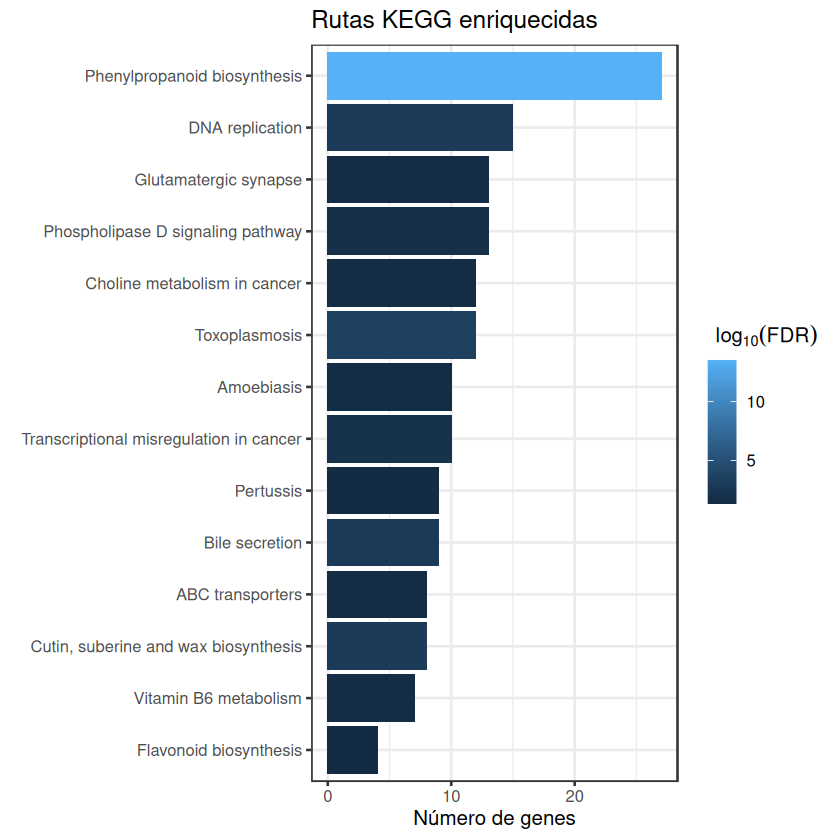

In [2]:
library(ggplot2)
library(dplyr)

kegg_plot <- kegg_res %>%
  mutate(
    minusLog10FDR = -log10(p.adjust)
  ) %>%
  arrange(Count) %>%
  mutate(
    Description = factor(
      Description,
      levels = Description
    )
  )

p <- ggplot(
  kegg_plot,
  aes(
    x = Description,
    y = Count,
    fill = minusLog10FDR
  )
) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(
    name = expression(-log[10](FDR))
  ) +
  labs(
    title = "Rutas KEGG enriquecidas",
    x = NULL,
    y = "Número de genes"
  ) +
  theme_bw(base_size = 12)

print(p)

ggsave(
  "KEGG_Barplot_Count_FDR.png",
  p,
  width = 10,
  height = 7,
  dpi = 300
)

Número de KO en map00941: 11 


[1] "K00475" "K00487" "K00588" "K00660" "K01859" "K05277" "K05278" "K09754"
 [9] "K13065" "K13082" "K13083"

,gene,KO,logFC,padj
,<chr>,<chr>,<dbl>,<dbl>
1,pelegrina_gene1_i1,K04382,0.5765677,3.560174e-03
2,pelegrina_gene100026_i1,K11434,0.4708133,6.056008e-13
3,pelegrina_gene100026_i1,K11437,0.4708133,6.056008e-13
4,pelegrina_gene100041_i1,K17744,0.1191645,2.558972e-01
5,pelegrina_gene10011_i8,K21867,-0.2529795,1.029110e-02
6,pelegrina_gene1001843_i1,K18468,-0.1441615,4.542295e-02




##############################################################################
Pathview is an open source software package distributed under GNU General
Public License version 3 (GPLv3). Details of GPLv3 is available at
http://www.gnu.org/licenses/gpl-3.0.html. Particullary, users are required to
formally cite the original Pathview paper (not just mention it) in publications
or products. For details, do citation("pathview") within R.

The pathview downloads and uses KEGG data. Non-academic uses may require a KEGG
license agreement (details at http://www.kegg.jp/kegg/legal.html).
##############################################################################



Número de KO en map00941: 11 
Número de genes asociados: 39 
                        gene     KO      logFC
1   pelegrina_gene1845786_i2 K13082 16.3747811
2  pelegrina_gene1215517_i26 K13082 -7.0213432
3   pelegrina_gene1312472_i5 K13065  2.8901355
4    pelegrina_gene827437_i1 K05278 -2.5320678
5   pelegrina_gene1006417_i1 K00588  1.3533075
6   pelegrina_gene1313605_i3 K00660 -0.9845656
7  pelegrina_gene1024788_i12 K00660 -0.8414472
8   pelegrina_gene1028363_i1 K13065 -0.6604049
9   pelegrina_gene1167382_i3 K00487  0.6118590
10   pelegrina_gene834525_i4 K00660 -0.5954944
11  pelegrina_gene1336121_i1 K09754  0.5945753
12  pelegrina_gene833261_i10 K13065  0.4694425
13   pelegrina_gene834526_i1 K00660 -0.3768032
14     pelegrina_gene7310_i1 K00660  0.3447635
15   pelegrina_gene838272_i2 K00475  0.3390748
16     pelegrina_gene2622_i1 K05278 -0.3089689
17    pelegrina_gene8467_i26 K00660  0.2974455
18  pelegrina_gene1952650_i1 K00660  0.2904101
19  pelegrina_gene1347213_i2 K05278 -0.2513857

Note: Only KEGG ortholog gene ID is supported, make sure it looks like "K01488"!

Note: Mapping via KEGG gene ID (not Entrez) is supported for this species,
it looks like "K01488"!

Info: Working in directory /home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA

Info: Writing image file ko00941.pathview.png



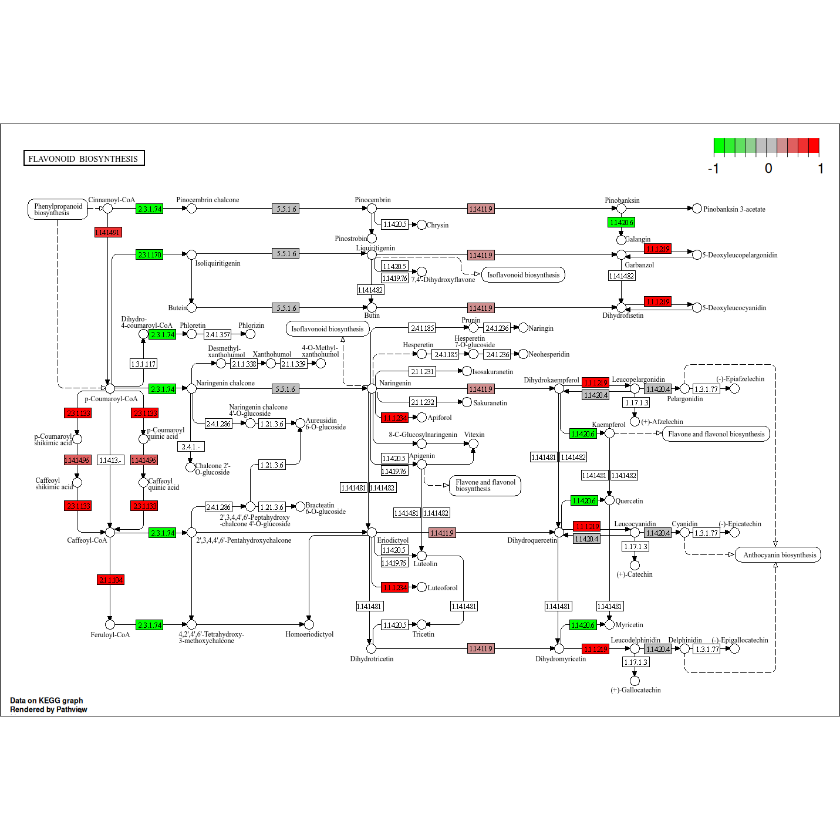

In [3]:
ko_00941 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map00941"
  ]
)

cat(
  "Número de KO en map00941:",
  length(ko_00941),
  "\n"
)

sort(ko_00941)

# =====================================================
# Crear gene_fc_ko
# =====================================================

gene_fc_ko <- merge(
  ko_gene,
  data.frame(
    gene = rownames(res_df),
    logFC = res_df$log2FoldChange,
    padj = res_df$padj
  ),
  by = "gene"
)

head(gene_fc_ko)

# =====================================================
# GENES DE LA RUTA map00941
# Flavonoid biosynthesis
# =====================================================

library(dplyr)
library(pathview)
library(png)
library(grid)

# =====================================================
# KO presentes en map00941
# =====================================================

ko_00941 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map00941"
  ]
)

cat(
  "Número de KO en map00941:",
  length(ko_00941),
  "\n"
)

# =====================================================
# Genes asociados
# =====================================================

genes_00941 <- gene_fc_ko %>%
  filter(KO %in% ko_00941)

cat(
  "Número de genes asociados:",
  length(unique(genes_00941$gene)),
  "\n"
)

# =====================================================
# Cargar InterProScan
# =====================================================

interpro <- read.delim(
  "/home/pazzz/Escritorio/GTF/DE_alstroemeria/anotacionInterpro/pelegrina_pf.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(interpro) <- c(
  "gene","md5","length","db","pfam","pfam_desc",
  "start","end","evalue","status","date",
  "ipr","ipr_desc","go","pathway"
)

interpro$gene <- sub(
  "\\.p[0-9]+$",
  "",
  interpro$gene
)

# =====================================================
# Consolidar anotaciones
# =====================================================

interpro_unique <- interpro %>%
  group_by(gene) %>%
  summarise(
    pfam = paste(unique(na.omit(pfam)), collapse = "; "),
    pfam_desc = paste(unique(na.omit(pfam_desc)), collapse = "; "),
    ipr = paste(unique(na.omit(ipr)), collapse = "; "),
    ipr_desc = paste(unique(na.omit(ipr_desc)), collapse = "; "),
    .groups = "drop"
  )

# =====================================================
# Unir con InterPro
# =====================================================

genes_00941_clean <- genes_00941 %>%
  left_join(interpro_unique, by = "gene") %>%
  distinct(
    gene,
    KO,
    logFC,
    .keep_all = TRUE
  ) %>%
  arrange(
    desc(abs(logFC))
  )

# =====================================================
# Top genes
# =====================================================

print(
  genes_00941_clean %>%
    select(
      gene,
      KO,
      logFC,
      pfam_desc,
      ipr_desc
    ) %>%
    head(20)
)

# =====================================================
# Guardar tabla completa
# =====================================================

write.csv(
  genes_00941_clean,
  "Flavonoid_biosynthesis_genes_annotated.csv",
  row.names = FALSE
)

# =====================================================
# Resumen por KO
# =====================================================

ko_summary_00941 <- genes_00941_clean %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_abs_logFC = max(abs(logFC), na.rm = TRUE),
    mean_logFC = mean(logFC, na.rm = TRUE),

    example_function = dplyr::first(
      ipr_desc[
        !is.na(ipr_desc) &
        ipr_desc != ""
      ]
    ),

    .groups = "drop"
  ) %>%
  arrange(desc(max_abs_logFC))

print(
  ko_summary_00941,
  n = nrow(ko_summary_00941)
)

# =====================================================
# DEGs importantes
# =====================================================

genes_00941_deg <- genes_00941_clean %>%
  filter(abs(logFC) >= 2)

cat(
  "\nGenes con |logFC| >= 2:",
  nrow(genes_00941_deg),
  "\n"
)

write.csv(
  genes_00941_deg,
  "Flavonoid_biosynthesis_DEGs.csv",
  row.names = FALSE
)

# =====================================================
# KO presentes
# =====================================================

cat("\nKO presentes en map00941:\n")

print(
  sort(
    unique(
      genes_00941_clean$KO
    )
  )
)

# =====================================================
# Pathview
# =====================================================

fc_vector_00941 <- genes_00941 %>%
  group_by(KO) %>%
  slice_max(
    abs(logFC),
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

fc_vector <- fc_vector_00941$logFC
names(fc_vector) <- fc_vector_00941$KO

pathview(
  gene.data = fc_vector,
  pathway.id = "00941",
  species = "ko",
  kegg.native = TRUE
)

# =====================================================
# Mostrar pathway
# =====================================================

img <- readPNG(
  "ko00941.pathview.png"
)

grid.newpage()
grid.raster(img)

In [4]:
candidatos_flavonoides <- genes_00941_clean %>%
  filter(
    abs(logFC) >= 2,
    padj < 0.01
  ) %>%
  arrange(padj)

In [5]:
ko_interes <- c(
  "K00660",  # CHS
  "K01859",  # CHI
  "K13082",  # DFR
  "K00475",  # F3H
  "K00487"   # CYP450
)

candidatos_finales <- genes_00941_clean %>%
  filter(
    KO %in% ko_interes,
    abs(logFC) >= 2,
    padj < 0.01
  ) %>%
  arrange(desc(abs(logFC)))

In [6]:
genes_00941_clean %>%
  filter(
    KO %in% c(
      "K00660",
      "K01859",
      "K13082",
      "K00475",
      "K00487"
    )
  ) %>%
  select(
    gene,
    KO,
    logFC,
    padj,
    ipr_desc
  ) %>%
  arrange(desc(abs(logFC)))

gene,KO,logFC,padj,ipr_desc
<chr>,<chr>,<dbl>,<dbl>,<chr>
pelegrina_gene1845786_i2,K13082,16.374781092,7.392031e-42,NAD(P)-dependent dehydratase-like; NAD-dependent epimerase/dehydratase
pelegrina_gene1215517_i26,K13082,-7.021343220,9.979167e-06,NAD(P)-dependent dehydratase-like; NAD-dependent epimerase/dehydratase
pelegrina_gene1313605_i3,K00660,-0.984565647,5.623494e-14,"Polyketide synthase, type III; Chalcone/stilbene synthase, N-terminal; Chalcone/stilbene synthase, C-terminal"
pelegrina_gene1024788_i12,K00660,-0.841447209,7.680396e-19,"Polyketide synthase, type III; Chalcone/stilbene synthase, C-terminal; Chalcone/stilbene synthase, N-terminal"
pelegrina_gene1167382_i3,K00487,0.611858957,3.545478e-08,-; Cytochrome P450
pelegrina_gene834525_i4,K00660,-0.595494358,4.547605e-18,"Polyketide synthase, type III; Chalcone/stilbene synthase, N-terminal; Chalcone/stilbene synthase, C-terminal"
pelegrina_gene834526_i1,K00660,-0.376803241,4.534305e-02,"Chalcone/stilbene synthase, C-terminal; Polyketide synthase, type III; Chalcone/stilbene synthase, N-terminal"
pelegrina_gene7310_i1,K00660,0.344763509,5.868324e-01,"Chalcone/stilbene synthase, N-terminal; Chalcone/stilbene synthase, C-terminal; Polyketide synthase, type III"
pelegrina_gene838272_i2,K00475,0.339074756,3.621204e-02,"Non-haem dioxygenase, N-terminal domain; Isopenicillin N synthase-like, Fe(2+) 2OG dioxygenase domain; Plant 2-oxoglutarate-dependent oxidoreductases"


Candidatos principales

| Prioridad | KO     | Gen                       | Función                         | logFC | padj     |
| --------- | ------ | ------------------------- | ------------------------------- | ----- | -------- |
| 1         | K13082 | pelegrina_gene1845786_i2  | Dihydroflavonol reductase (DFR) | 16.37 | 7.39e-42 | MSA listo 
| 2         | K13082 | pelegrina_gene1215517_i26 | Dihydroflavonol reductase (DFR) | -7.02 | 9.98e-06 |
| 3         | K00660 | pelegrina_gene1313605_i3  | Chalcone synthase (CHS)         | -0.98 | 5.62e-14 |
| 4         | K00660 | pelegrina_gene1024788_i12 | Chalcone synthase (CHS)         | -0.84 | 7.68e-19 |
|           |        | pelegrina_gene1156448_i15 | DFR                             | 15.43 | 3.86E-37 |

CANDIDATOS
| Prioridad | KO     | Función                                    | Evidencia                                                 |
| --------- | ------ | ------------------------------------------ | --------------------------------------------------------- |
| 1         | K00660 | Chalcone synthase (CHS)                    | Primer paso comprometido de la biosíntesis de flavonoides |
| 2         | K01859 | Chalcone isomerase (CHI)                   | Segundo paso de la ruta                                   |
| 3         | K00487 | Cinnamate 4-hydroxylase (C4H)              | Conecta fenilpropanoides con flavonoides                  |
| 4         | K00588 | O-methyltransferase                        | Modifica flavonoides finales                              |
| 5         | K05278 | Flavanone 3-dioxygenase / 2-OG dioxygenase | Participa en síntesis de flavonoles y antocianinas        |
| 6         | K13065 | Acyltransferase                            | Modificación final de pigmentos                           |


|     GENES DE K00660         |       GENES DE K05278         | 
|-------------------------    |     ----------------------    |
|pelegrina_gene1313605_i3     |     pelegrina_gene827437_i1   | 
|pelegrina_gene1024788_i12    |     pelegrina_gene2622_i1     |
|pelegrina_gene834525_i4      |     pelegrina_gene1347213_i2  |
|pelegrina_gene834526_i1      |     pelegrina_gene823832_i1   |
|pelegrina_gene7310_i1        |                               |
|pelegrina_gene8467_i26       |                               |
|pelegrina_gene1952650_i1     |                               |


...

In [7]:
gene2path %>%
 filter(KO == "K13082")

KO,gene,Pathway
<chr>,<chr>,<chr>
K13082,pelegrina_gene1215517_i26,map01110
K13082,pelegrina_gene1215517_i26,map01100
K13082,pelegrina_gene1215517_i26,map00941
K13082,pelegrina_gene1845786_i2,map01110
K13082,pelegrina_gene1845786_i2,map01100
K13082,pelegrina_gene1845786_i2,map00941
K13082,pelegrina_gene826226_i6,map01110
K13082,pelegrina_gene826226_i6,map01100
K13082,pelegrina_gene826226_i6,map00941


BARPLOT DE LAS RUTAS ENRIQUECIDAS ASOCIADAS A PLANTAS 

In [ ]:
library(ggplot2)
library(dplyr)
library(stringr)

plot_data <- data.frame(
  ID = c("map00940", "map00073", "map03030", "map04072", "map02010", "map00750", "map00941"),
  Description = c(
    "Phenylpropanoid biosynthesis",
    "Cutin, suberine and wax biosynthesis",
    "DNA replication",
    "Phospholipase D signaling pathway",
    "ABC transporters",
    "Vitamin B6 metabolism",
    "Flavonoid biosynthesis"
  ),
  Count = c(27, 8, 15, 13, 8, 7, 4),
  p.adjust = c(3.07e-14, 9.76e-4, 9.76e-4, 1.40e-2, 2.96e-2, 3.45e-2, 4.60e-2)
)

# Ordenar el factor 'Description' basado en 'Count' 
# Esto asegura que la barra más larga (27 genes) aparezca arriba del todo en el gráfico
plot_data <- plot_data %>%
  mutate(Description = reorder(Description, Count))

# 2. Construcción del gráfico con ggplot2, VOLVIENDO A LA PALETA PLASMA
p <- ggplot(plot_data, aes(x = Count, y = Description, fill = p.adjust)) +
  # Barras con bordes negros finos y limpios
  geom_col(width = 0.7, color = "black", size = 0.3) +
  
  # --- PALETA DE COLORES PLASMA ---
  # Volvemos a scale_fill_viridis_c con option="plasma".
  # direction = -1 asegura que los valores pequeños (más significativos) sean oscuros/contrastantes.
  scale_fill_viridis_c(
    option = "plasma", 
    direction = -1,
    name = expression(italic("p") * "-adjust"),
    trans = "log10", # Mantenemos log10 debido al rango drástico de p-values
    guide = guide_colorbar(ticks.colour = "black", frame.colour = "black", barheight = 10)
  ) +
  
  # Etiquetas formales de publicación
  labs(
    x = "Gene Count",
    y = "KEGG Pathway",
    title = "KEGG Pathway Enrichment Analysis",
    subtitle = "Significantly enriched pathways associated with plant pigments and metabolism"
  ) +
  
  # Ajustar márgenes del eje horizontal
  scale_x_continuous(expand = expansion(mult = c(0, 0.1))) +
  
  # --- TEMA MINIMALISTA DE PUBLICACIÓN (mantenemos la estructura profesional) ---
  theme_bw(base_size = 11, base_family = "sans") + 
  theme(
    # Cuadro exterior sólido
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    # Líneas de grilla verticales discontinuas
    panel.grid.major.x = element_line(color = "gray92", linetype = "dashed"),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_blank(),
    
    # Textos nítidos y legibles
    axis.text.y = element_text(color = "black", size = 10),
    axis.text.x = element_text(color = "black", size = 10),
    axis.title = element_text(color = "black", face = "bold", size = 11),
    
    # Títulos del gráfico
    plot.title = element_text(face = "bold", size = 13, margin = margin(b = 4)),
    plot.subtitle = element_text(color = "gray30", size = 9.5, margin = margin(b = 15)),
    
    # Leyenda estilizada a la derecha
    legend.position = "right",
    legend.title = element_text(size = 9.5, face = "bold"),
    legend.text = element_text(size = 8.5)
  )

# 3. Guardar en alta resolución
ggsave(
  "KEGG_Plant_Pigments_Plasma.pdf",
  plot = p,
  width = 8.5,
  height = 4.5,
  device = "pdf",
  useDingbats = FALSE
)

ggsave(
  "KEGG_Plant_Pigments_Plasma.png",
  plot = p,
  width = 8.5,
  height = 4.5,
  dpi = 300
)

Warning message in geom_col(width = 0.7, color = "black", size = 0.3):
“Ignoring unknown parameters: `size`”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [9]:
library(KEGGREST)

kos <- unique(genes_00941_clean$KO)

ko_ec <- lapply(kos, function(k){

  info <- keggGet(k)[[1]]

  data.frame(
    KO = k,
    EC = paste(info$ENZYME, collapse=";"),
    NAME = info$NAME[1]
  )

})

ko_ec <- do.call(rbind, ko_ec)
ko_ec

KO,EC,NAME
<chr>,<chr>,<chr>
K13082,,bifunctional dihydroflavonol 4-reductase/flavanone 4-reductase [EC:1.1.1.219 1.1.1.234]
K13065,,shikimate O-hydroxycinnamoyltransferase [EC:2.3.1.133]
K05278,,flavonol synthase [EC:1.14.20.6]
K00588,,caffeoyl-CoA O-methyltransferase [EC:2.1.1.104]
K00660,,chalcone synthase [EC:2.3.1.74]
K00487,,trans-cinnamate 4-monooxygenase [EC:1.14.14.91]
K09754,,5-O-(4-coumaroyl)-D-quinate 3'-monooxygenase [EC:1.14.14.96]
K00475,,naringenin 3-dioxygenase [EC:1.14.11.9]
K01859,,chalcone isomerase [EC:5.5.1.6]


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message in plot_theme(plot):
“The `plot.subtitle.position` theme element is not defined in the element
hierarchy.”
Warning message:
“Removed 72 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in plot_theme(plot):
“The `plot.subtitle.position` theme element is not defined in the element
hierarchy.”
Warning message:
“Removed 72 rows containing missing values or values outside the scale range
(`geom_point()`).”


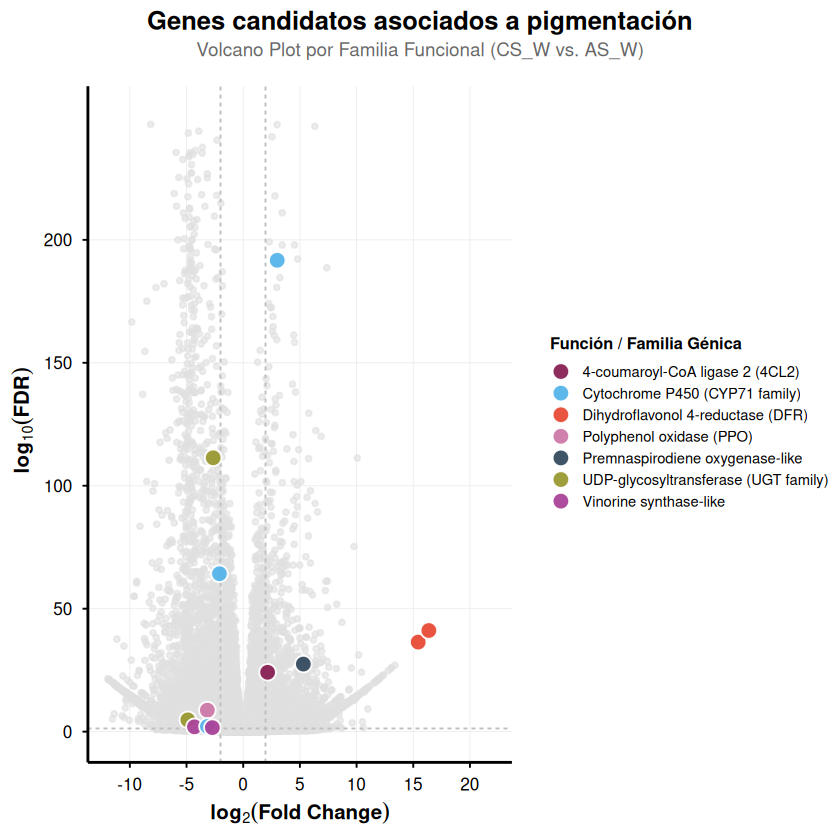

In [10]:
library(dplyr)
library(ggplot2)

#=========================================================
# 1. Nueva Tabla de Descripciones Funcionales Limpias (CS_W vs AS_W)
#=========================================================
descripciones_completa <- data.frame(
  gene = c(
    "pelegrina_gene1037623_i3", "pelegrina_gene823968_i2", "pelegrina_gene1039844_i1",
    "pelegrina_gene1452632_i3", "pelegrina_gene1913168_i5", "pelegrina_gene1168858_i3",
    "pelegrina_gene829540_i1", "pelegrina_gene1057551_i1", "pelegrina_gene835130_i1",
    "pelegrina_gene1164041_i10", "pelegrina_gene1156448_i15", "pelegrina_gene1845786_i2"
  ),
  family = c(
    "Polyphenol oxidase (PPO)",
    "Cytochrome P450 (CYP71 family)",
    "UDP-glycosyltransferase (UGT family)",
    "Cytochrome P450 (CYP71 family)",
    "Vinorine synthase-like",
    "Vinorine synthase-like",
    "4-coumaroyl-CoA ligase 2 (4CL2)",
    "Cytochrome P450 (CYP71 family)",
    "Premnaspirodiene oxygenase-like",
    "UDP-glycosyltransferase (UGT family)",
    "Dihydroflavonol 4-reductase (DFR)",
    "Dihydroflavonol 4-reductase (DFR)"
  ),
  stringsAsFactors = FALSE
)

#=========================================================
# 2. Preparar datos
#=========================================================
res_plot <- res_df %>%
  filter(!is.na(padj), padj > 0) %>%
  mutate(
    gene = rownames(.),
    regulation = case_when(
      padj < padj_cutoff & log2FoldChange >= lfc_cutoff ~ "Sobreexpresado",
      padj < padj_cutoff & log2FoldChange <= -lfc_cutoff ~ "Subexpresado",
      TRUE ~ "No significativo"
    )
  )

# Unir con las descripciones funcionales
res_plot <- left_join(res_plot, descripciones_completa, by="gene")

# Separar datos: fondo (gris) y destacados (color)
genes_fondo <- res_plot %>% filter(is.na(family))
genes_color <- res_plot %>% filter(!is.na(family))

#=========================================================
# 3. Paleta de Colores Estandarizada
#=========================================================
colores_familias <- c(
  "4-coumaroyl-CoA ligase 2 (4CL2)"       = "#882255",
  "Cytochrome P450 (CYP71 family)"        = "#56B4E9",
  "Dihydroflavonol 4-reductase (DFR)"     = "#E64B35FF", # Rojo coral llamativo para DFR
  "Polyphenol oxidase (PPO)"              = "#CC79A7",
  "Premnaspirodiene oxygenase-like"       = "#354B5E",
  "UDP-glycosyltransferase (UGT family)"  = "#999933",
  "Vinorine synthase-like"                = "#AA4499"
)

#=========================================================
# 4. Volcano Plot
#=========================================================
p1_proportional <- ggplot() +

  ## Capa de Fondo: Todos los genes no anotados/comunes
  geom_point(
    data = genes_fondo,
    aes(x = log2FoldChange, y = -log10(padj)),
    color = "grey88",
    size = 1.0,
    alpha = 0.6
  ) +

  ## Líneas de corte sutiles (Hereda dinámicamente tu lfc_cutoff = 2)
  geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "grey75", size = 0.4) +
  geom_hline(yintercept = -log10(padj_cutoff), linetype = "dashed", color = "grey75", size = 0.4) +

  ## Capa Principal: Puntos de las familias (Formato de alta resolución)
  geom_point(
    data = genes_color,
    aes(x = log2FoldChange, y = -log10(padj), fill = family),
    shape = 21,         
    color = "white",    
    stroke = 0.6,       
    size = 4.0,         
    alpha = 0.95
  ) +

  ## Escalas de colores (Mapeado a fill)
  scale_fill_manual(
    name = "Función / Familia Génica",
    values = colores_familias
  ) +

  ## Etiquetas de ejes y títulos
  labs(
    title = "Genes candidatos asociados a pigmentación",
    subtitle = "Volcano Plot por Familia Funcional (CS_W vs. AS_W)",
    x = expression(bold(log[2]("Fold Change"))),
    y = expression(bold(-log[10]("FDR")))
  ) +

  ## Ajuste estricto de ejes
  scale_x_continuous(limits = c(-12, 22), breaks = seq(-10, 20, by = 5)) +
  scale_y_continuous(limits = c(0, 250), breaks = seq(0, 200, by = 50)) +

  ## Tema de publicación y centrado absoluto respecto al lienzo
  theme_minimal(base_size = 13) +
  theme(
    plot.title.position = "plot",    
    plot.subtitle.position = "plot", 
    plot.title = element_text(face = "bold", hjust = 0.5, size = 15, color = "black"),
    plot.subtitle = element_text(hjust = 0.5, size = 11, color = "grey40", margin = margin(t = -3, b = 15)),
    
    # Ejes
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10, color = "black"),
    axis.line = element_line(size = 0.6, color = "black"),
    axis.ticks = element_line(size = 0.4, color = "black"),

    # Leyenda lateral balanceada
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 9.5), 
    legend.text = element_text(size = 8.5),                 
    legend.key.size = unit(0.9, "lines"), 
    legend.margin = margin(0, 0, 0, 10),
    
    # Grid sutil de fondo
    panel.grid.major = element_line(size = 0.2, color = "grey93"),
    panel.grid.minor = element_blank()
  )

#=========================================================
# 5. Guardar gráfico con alta resolución
#=========================================================
ggsave(
  filename = "Volcano_CSW_vs_ASW_Families.png",
  plot = p1_proportional,
  width = 11.5,     
  height = 7.0,
  dpi = 300,
  bg = "white"
)

print(p1_proportional)